In [2]:
import os
import sys 
sys.path.append(os.path.abspath(os.path.join("..", "..")))
from evoked.io import load_bulk, save_results_xlsx
from evoked.preprocess import preprocess
from evoked.template import match_feature
from evoked.plotting import plot_trace, plot_io_curve, plot_fit, plot_detected, plot_all_files
from evoked.base import RecordingResult, PreprocessParams
import matplotlib.pyplot as plt

## I. Determine which files are for training and testing
1. Set `base_path` to the folder path with your .abf files
2. Change `repnum` to how many repeats were recorded per stimulus intensity. A warning will display if a file contained an unexpected number of total traces. In this case, resave your .abf file with that extra trace removed.
3. Change `intensities` in `plot_all_files` depending on which stimuli you want to use for your template.
4. Experienced users may mess with `PreprocessParams`, but this is not recommended.

c:\Users\bbyer\OneDrive\Documents\UniversityofKentucky\BachstetterLab\evoked_user_test\evoked\src\evoked\io.py:145: UserWarning: 
Skipping C:\Users\bbyer\OneDrive\Documents\UniversityofKentucky\BachstetterLab\evoked\evoked_broken\src\data\newdata_ca1\2026_06_01_0003.abf: C:\Users\bbyer\OneDrive\Documents\UniversityofKentucky\BachstetterLab\evoked\evoked_broken\src\data\newdata_ca1\2026_06_01_0003.abf: expected 33 sweeps, got 34. This file will be omitted from quantification.
  warnings.warn(
c:\Users\bbyer\OneDrive\Documents\UniversityofKentucky\BachstetterLab\evoked_user_test\evoked\src\evoked\io.py:145: UserWarning: 
Skipping C:\Users\bbyer\OneDrive\Documents\UniversityofKentucky\BachstetterLab\evoked\evoked_broken\src\data\newdata_ca1\2026_06_01_0007.abf: C:\Users\bbyer\OneDrive\Documents\UniversityofKentucky\BachstetterLab\evoked\evoked_broken\src\data\newdata_ca1\2026_06_01_0007.abf: expected 33 sweeps, got 34. This file will be omitted from quantification.
  warnings.warn(


[<Figure size 1200x1000 with 6 Axes>,
 <Figure size 1200x1000 with 6 Axes>,
 <Figure size 1200x1000 with 6 Axes>,
 <Figure size 1200x1000 with 6 Axes>]

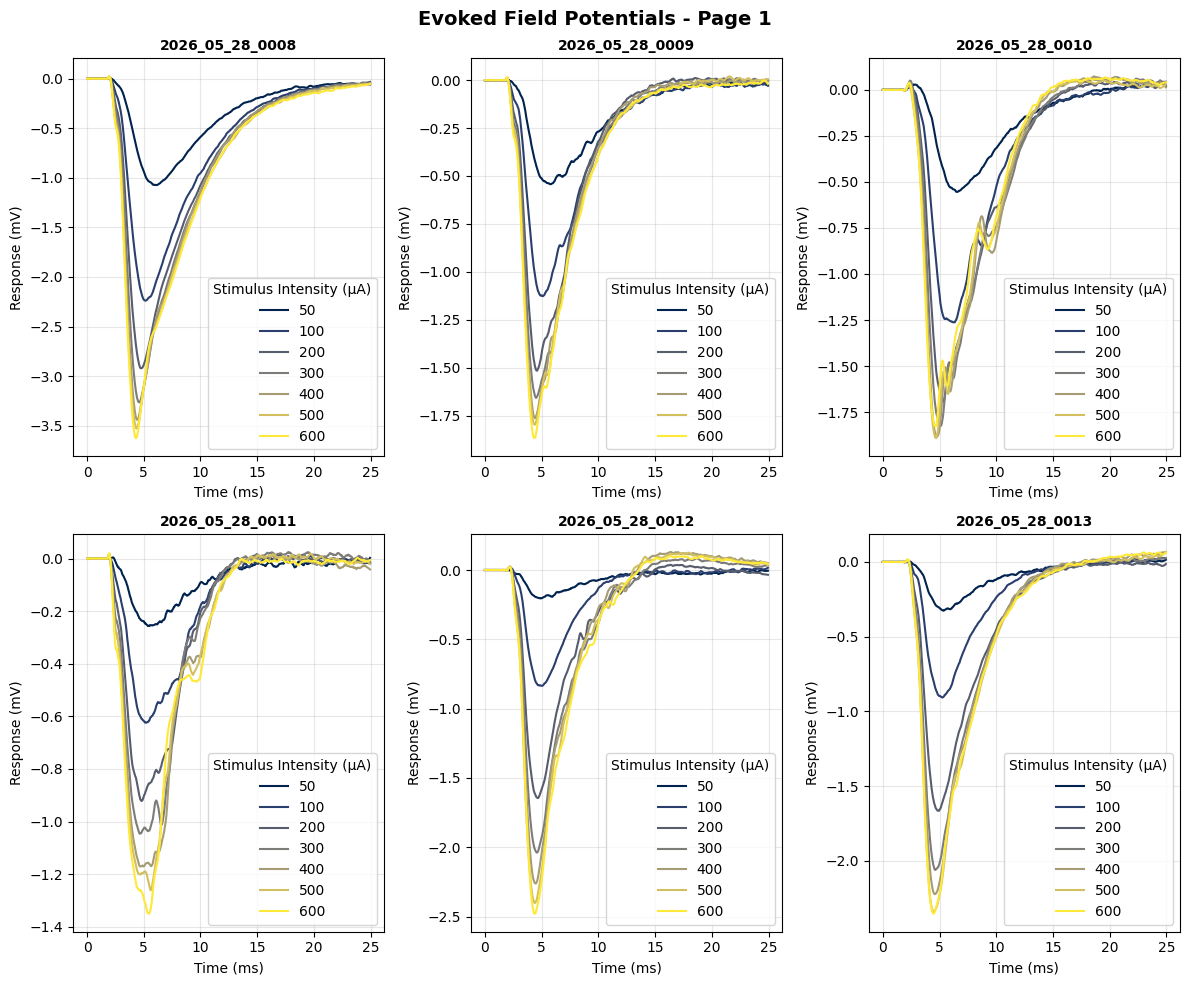

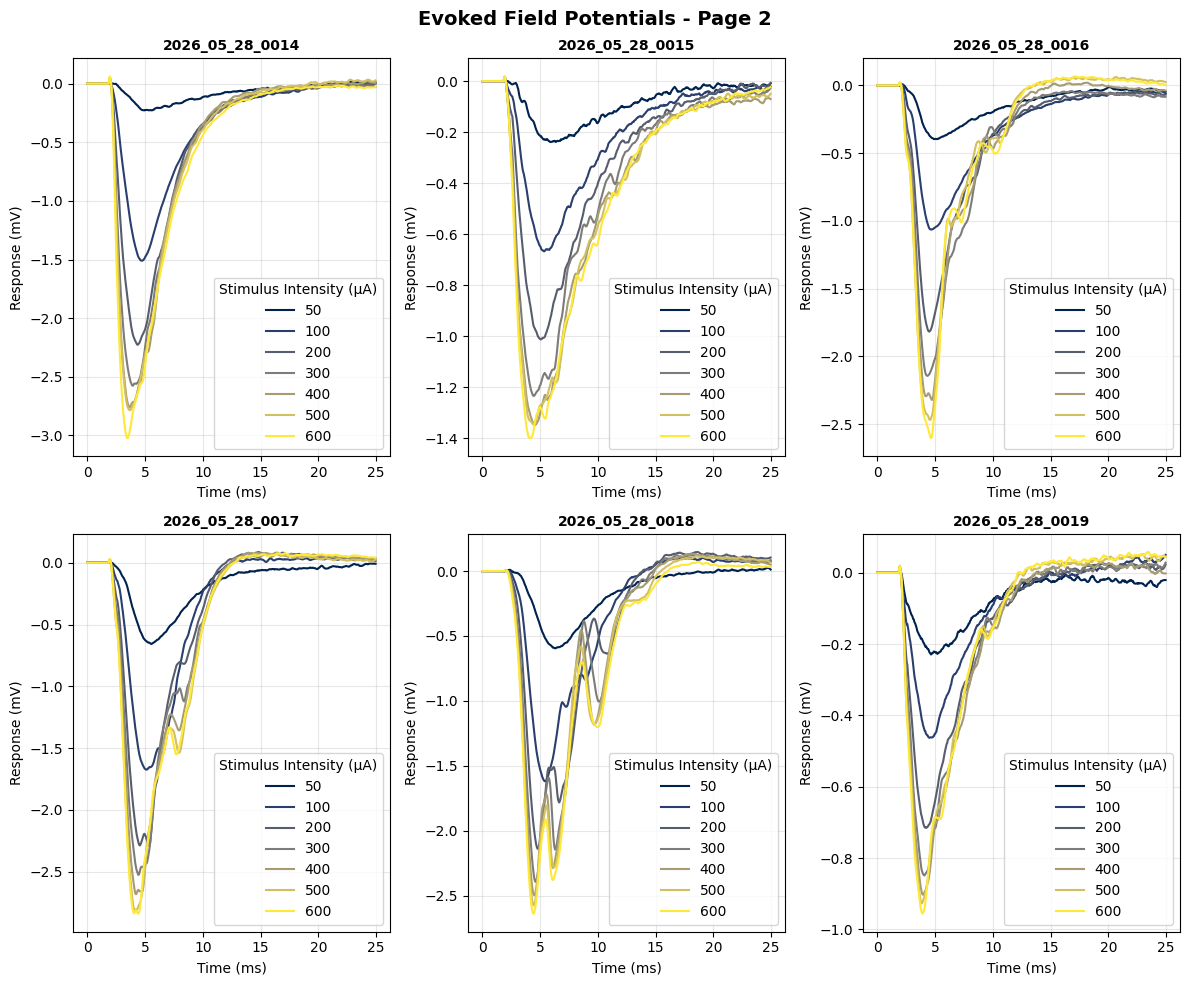

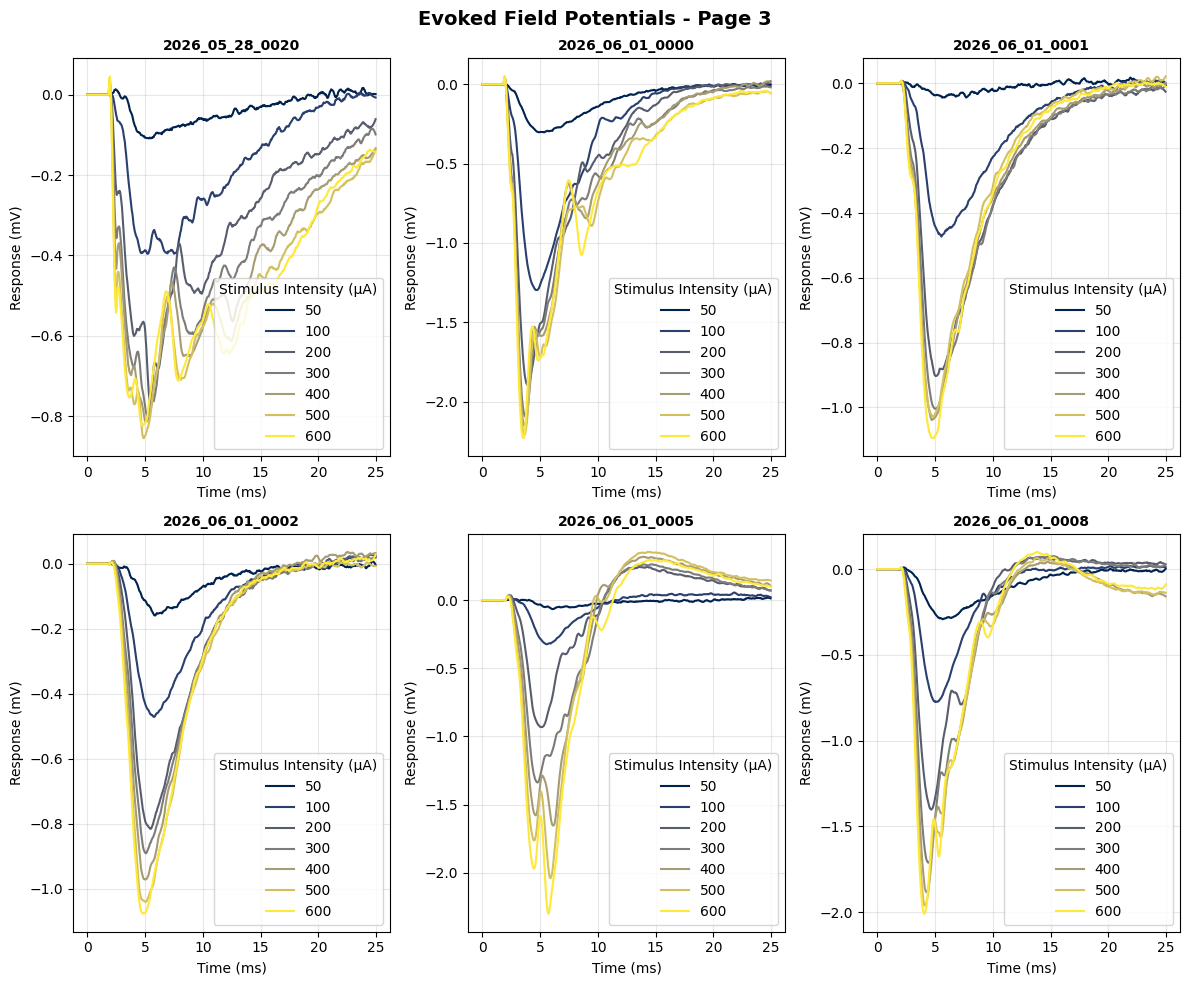

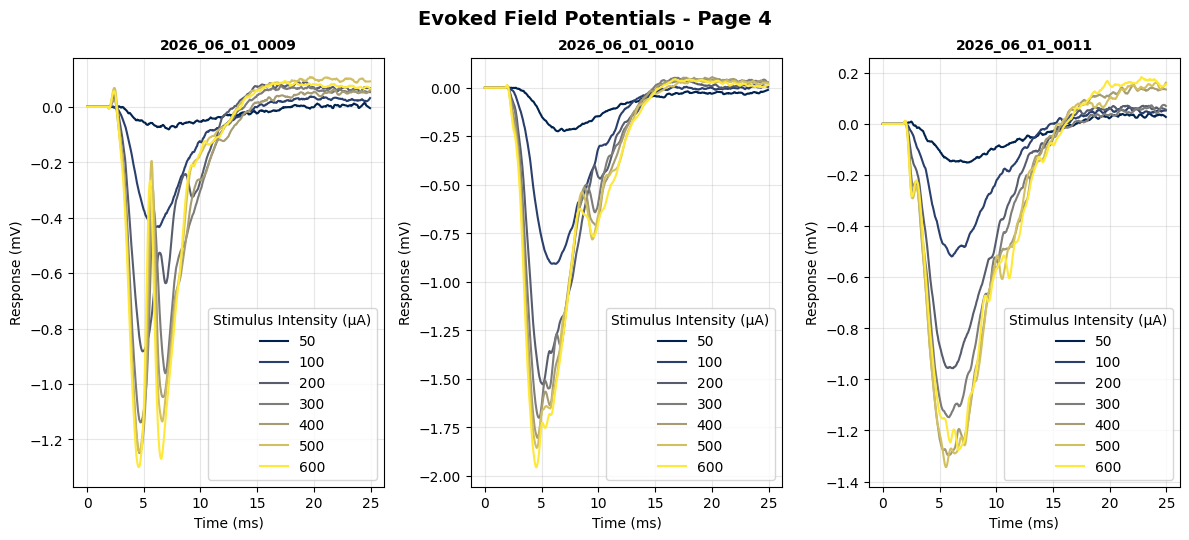

In [3]:
base_path = r"C:\Users\bbyer\OneDrive\Documents\UniversityofKentucky\BachstetterLab\evoked\evoked_broken\src\data\newdata_ca1"

# get all valid ABF files
all_files = [os.path.join(base_path, f) for f in os.listdir(base_path) if f.endswith('.abf')]

intensities_list = [25, 50, 75, 100, 150, 200, 250, 300, 400, 500, 600] 

params = PreprocessParams(
    baseline_window=(0, 0.1),
    artifact_window=(0, 2.25),
    artifact="template",
    smoothing="savgol",
    smoothing_params={
                        "size": 7,
                        "window_length": 15,
                        "polyorder": 2,
                        "cutoff": 2000.0,
                        "order": 2,
                    }
)

# load all files
all_raw = load_bulk(all_files, intensities=intensities_list, repnum=3)

# clean them up
all_prep = preprocess(all_raw, params)

# plot all traces to determine train/test split
plot_all_files(all_prep, intensities=[50, 100, 200, 300, 400, 500, 600], max_per_page=6)

## II. Make a train/test split and run the pipeline
1. Based on the look of the files above, I selected `train_files` for files I want to use as templates. Be careful here.
2. The `test_files` are just `all_files` minus `train_files`. If you want to change this behavior, make a list of `test_files` and join its path to the `base_path` using list comprehension.
3. Set template intensities at which you want to create a template (averaged trace). You can change this for each feature too. For instance, you might only want population spikes to look like what you see at higher stimuli.
4. Load the files in each split and preprocess them separately.
5. Load empty `RecordingResult`.
6. Add individual results. The format is `result.add("name", match_feature(**options))`. The key parameters you would change are:
    - the $R^2$ threshold (`r2_threshold`), which will determine if a feature is detected at that stimulus intensity/file (to be used later in `plot_detected`).
    - the `template_window` which is the window of the `train_files` that will be averaged to make a template. 
    - the `search_window` which is the window in the `test_files` that will be searched for the feature match.
    - `slope_transform=True` means do template matching in the slope domain (mV/ms) instead of mV. Do this for fEPSP.

In [4]:
train_ids = [
    "2026_05_28_0008", "2026_06_01_0011", "2026_06_01_0005", 
    "2026_05_28_0017", "2026_06_01_0009", "2026_06_01_0011", 
    "2026_06_01_0010", "2026_05_28_0020"
]

train_prep = all_prep[all_prep["id"].isin(train_ids)]
test_prep = all_prep[~all_prep["id"].isin(train_ids)]

template_ints = [300, 400, 500, 600]

ca1_results = RecordingResult(preprocess_params=params)

ca1_results.add("Fiber Volley", match_feature(
    train_df=train_prep, test_df=test_prep, 
    template_window=(1.5, 3.0), search_window=(1.0, 3.2), 
    template_intensities=template_ints, 
    r2_threshold=0.8,
    slope_transform=False
))

ca1_results.add("fEPSP", match_feature(
    train_df=train_prep, test_df=test_prep, 
    template_window=(3.0, 4.7), search_window=(2.5, 5.0), 
    template_intensities=template_ints, 
    r2_threshold=0.4,
    slope_transform=True
))

ca1_results.add("Population Spike", match_feature(
    train_df=train_prep, test_df=test_prep, 
    template_window=(4.5, 6.0), search_window=(4.0, 6.5), 
    template_intensities=template_ints, 
    r2_threshold=0.8,
    slope_transform=False
))

## III. Make cool plots
1. Set parameters. Use `id_value` to set which file you want to plot, `features` for the features you want to plot (which must be in the results object), `intensities/intensity` for intensities, `annotated=False` to show traces without features, and so on.
2. For matplotlib pros, you can optionally use `rc_params` as an argument to these functions to change the plot appearance or even change aspects of the figure with the figure object. For example, change the title to `ca1_trace_fig` with `ca1_trace_fig.suptitle("New title")`. An `rc_params` example would be `plot_io_curve(..., rc_params = {'lines.linewidth':3})`.

Warning: if the max correlation point is consistently at the edge of the `plot_fit` second column plots, then the `search_window` may be poorly specified (see above).

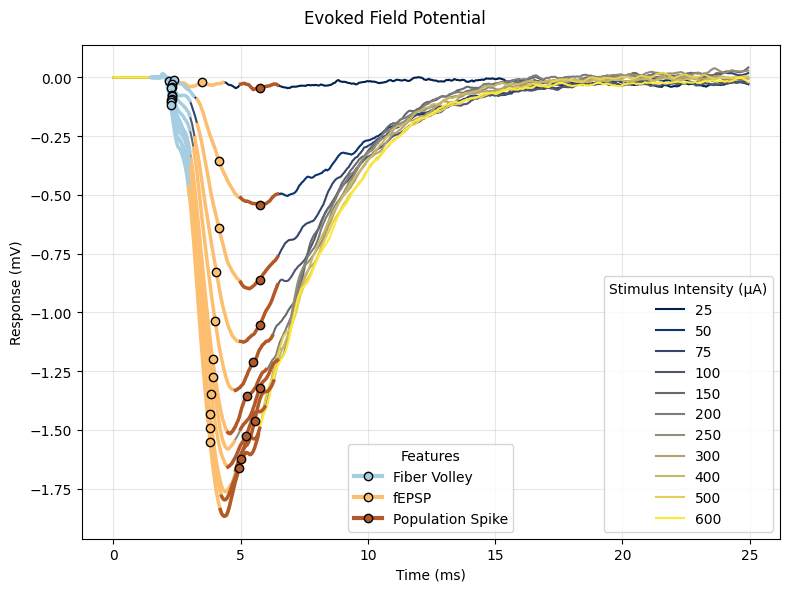

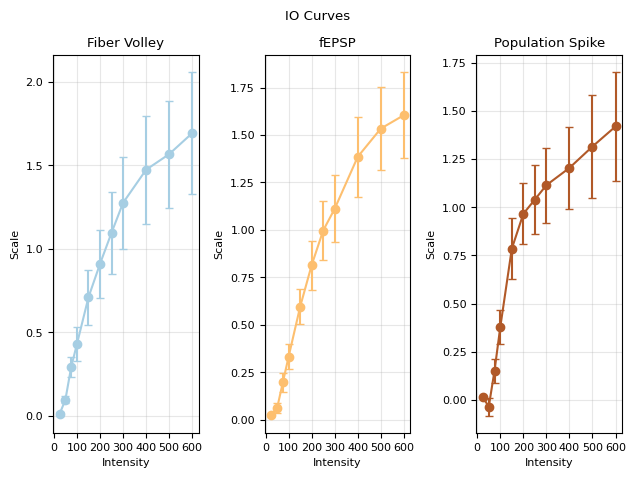

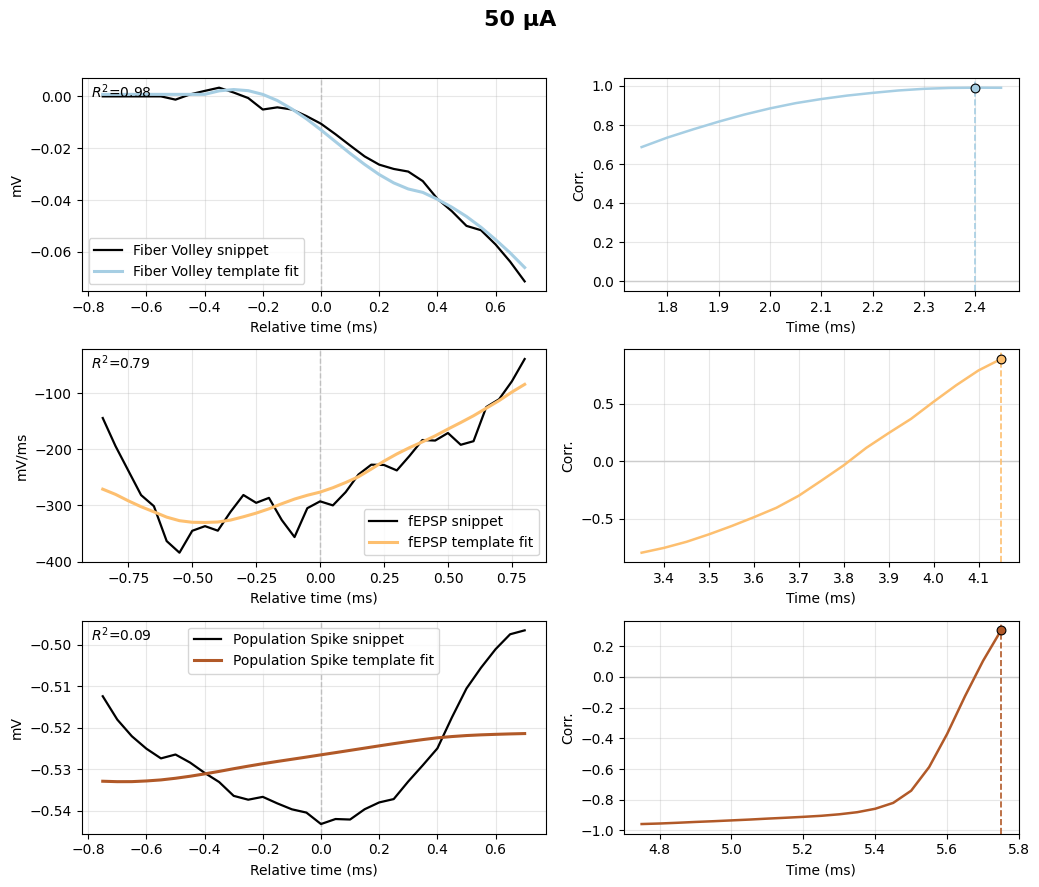

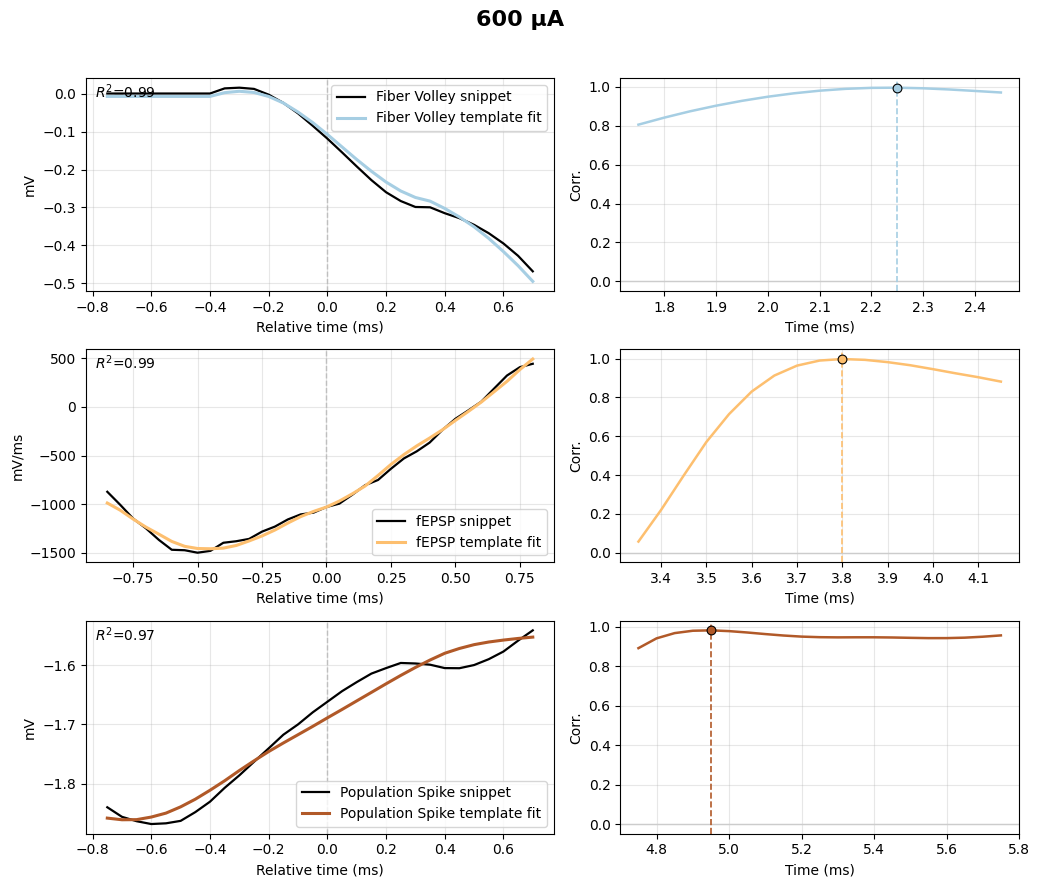

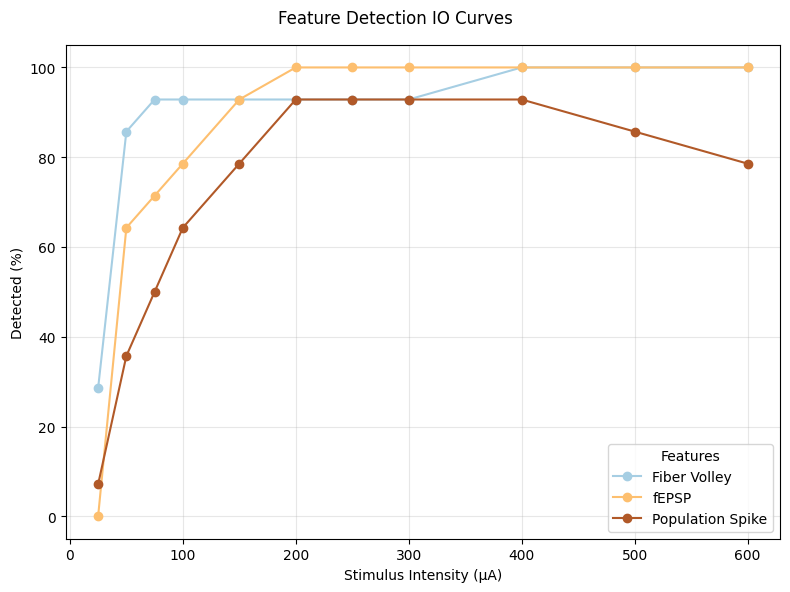

In [5]:
template_features = ["Fiber Volley", "fEPSP", "Population Spike"]
ca1_trace_fig, ca1_trace_ax = plot_trace(test_prep, recording_result=ca1_results, id_value='2026_05_28_0009', features=template_features, intensities=intensities_list, annotated=True)
ca1_io_fig, ca1_io_axes = plot_io_curve(ca1_results, features=template_features, intensities=intensities_list, rc_params={'font.size': 8})
ca1_fit_fig, ca1_fit_axes = plot_fit(test_prep, ca1_results, features=template_features, intensity=50, id_value='2026_05_28_0009')
ca1_fit_fig1, ca1_fit_axes1 = plot_fit(test_prep, ca1_results, features=template_features, intensity=600, id_value='2026_05_28_0009')
ca1_detected_fig, ca1_detected_axes = plot_detected(ca1_results, features=template_features)
plt.show()

## IV. Save results
1. Save results with `save_results_xlsx(results, filepath)`.
2. Save plots with matplotlib's "Save As" dialog box, or use `figname.savefig(options)`

In [6]:
save_results_xlsx(ca1_results, "ca1_2026_06_19.xlsx")
ca1_detected_fig.savefig("ca1_detected.png",dpi=600, bbox_inches="tight")